In [1]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
from scipy.interpolate import RegularGridInterpolator
from plant.battery import battery_step, coef_quad, Uoc,thermal_model
from plant.powertrain import powertrain
import sys, os
sys.path.append(os.path.abspath('..'))

In [2]:
#Define the parameters
Delta_t = 0.1

# Fuel consumption in grams per unit energy

Voc = params['V_oc_nom'] 
Q_bat = params['E_pack_capacity'] / Voc

# Limits on Batt Power, Eng Power, SOC
P_MGU_max = params['P_MGU_max']  # 350[kW]
P_MGU_min = params['P_MGU_min']  # -200[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SOC_min = params['SoC_min']     # 0.1[-]
SOC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']

# Load Data: of t,v,a
data = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/Canada_qualifying.npy')

t = data[0,:]
v = data[1,:]
a = data[2,:]

# Load Data: power at the gearbox
data_of_power_gb = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/power_domand.npy')
P_gb = data_of_power_gb[1,:]

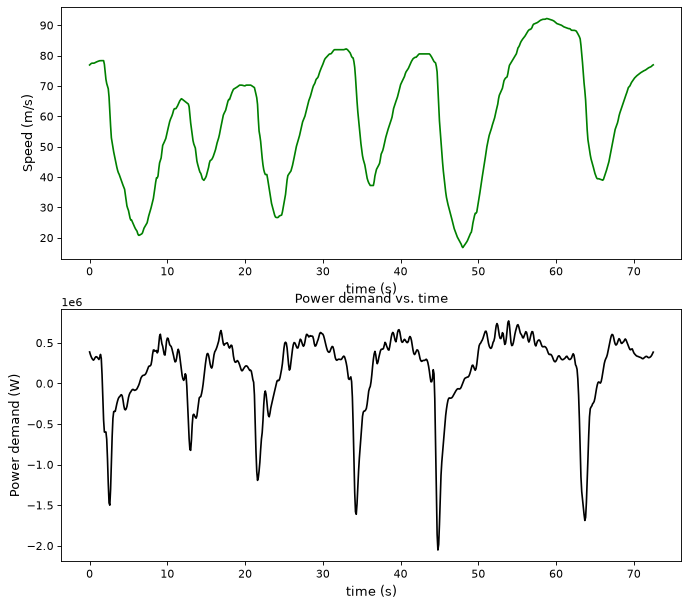

In [3]:
plot.figure(num=1, figsize=(10, 9), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(2,1,1)
plot.plot(t,v,'g')
plot.ylabel('Speed (m/s)', fontsize= 12)
plot.xlabel('time (s)', fontsize= 12)

plot.subplot(2,1,2)
plot.plot(t, P_gb, 'k')
plot.xlabel('time (s)', fontsize=12)
plot.ylabel('Power demand (W)', fontsize=12)
plot.title('Power demand vs. time', fontsize=12)
plot.show()

In [4]:
SoC_grid = np.linspace(SOC_min,SOC_max, 50)
E_ES2K_grid = np.linspace(0, E_ES2K_max, 50)

#Grid size
ns = len(SoC_grid) # No. of states
ne = len(E_ES2K_grid)

# Planning horizon (time steps)
N = len(t)

# Preallocate Value Function (rows index state, columns index time)
V = np.inf*np.ones((ns,ne,N+1))

# Preallocate Control (rows index state, columns index time)
u_star = np.zeros((ns,ne, N))
nu = 200

In [5]:
SoC_mesh, E_ES2K_mesh = np.meshgrid(SoC_grid,E_ES2K_grid, indexing='ij')

SoC_max_term = (SOC_max - SoC_mesh) * Q_bat * Uoc(SoC_mesh, coef_quad) / -Delta_t
SoC_min_term = (SOC_min - SoC_mesh) * Q_bat * Uoc(SoC_mesh, coef_quad) / -Delta_t
E_deploy_ub = (E_ES2K_max-E_ES2K_mesh)/Delta_t

# Boundary Condition of Value Function (Principle of Optimality)
V[:,:,N] = 0

for k in range(N-1,-1,-1):
    interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)
    if P_gb[k]>=0:
        lb = np.maximum(SoC_max_term, P_gb[k] - P_eng_max)
        ub = np.minimum(SoC_min_term,E_deploy_ub)
        ub = np.minimum(ub, np.minimum(P_MGU_max,P_gb[k]))
    else:
        lb = np.maximum(SoC_max_term, np.maximum(P_MGU_min, P_gb[k]))
        ub = np.minimum(SoC_min_term,0)
        
    P_mguk_mesh = np.linspace(lb, ub, nu, axis=-1)

    if P_gb[k]>=0:
        P_eng = P_gb[k] - P_mguk_mesh
    else:
        P_eng = np.zeros_like(P_mguk_mesh)
    

    m_dot = (P_eng + P_ICE0) / (eta_ICE * LHV)
    m_dot = np.clip(m_dot, 0, params['m_dot_max']/3600)

    # Cost-per-time-step, a.k.a. fuel consumed at each stage (vectorized for all P_batt_grid)
    g_k = m_dot * Delta_t

    # compute next SOC and E_ES2K using dynamics
    SoC_nxt = SoC_mesh[:,:,np.newaxis] - P_mguk_mesh*Delta_t/(Q_bat * Uoc(SoC_mesh[:, :, np.newaxis], coef_quad))
    E_ES2K_next = E_ES2K_mesh[:, :, np.newaxis] + np.maximum(P_mguk_mesh, 0)*Delta_t
    

    # Compute value function at nxt time step (need to interpolate)
    points = np.stack([SoC_nxt.ravel(), E_ES2K_next.ravel()], axis=-1)
    V_nxt = interp_Vnext(points).reshape(ns, ne, nu)
    V[:,:,k] = np.min(g_k + V_nxt, axis=2)

    idx = np.argmin(g_k + V_nxt, axis=2, keepdims=True)
            
    u_star[:,:,k] = np.take_along_axis(P_mguk_mesh,idx,axis=2).squeeze(axis=-1)

## Simulate optimal energy management results

Now that I've solved the DP, I can use the `u_star` \"map\" to optimize battery usage! I do this for five different starting battery charge to understand its impact on fuel consumption and final charge.

In [6]:
def optimize_PHEV(SOC_0,E_ES2K_0):
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    P_MGUK_sim = np.zeros(N)
    P_eng_sim = np.zeros(N)
    J_sim = np.zeros(N)
    m_dot_sim = np.zeros(N)
    shortfall = np.zeros(N)
    E_recharge_sim = np.zeros(N)
    P_mech_MGU_K_real= np.zeros(N)
    Tbat_sim = np.zeros(N)
    
    # Initialize
    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_recharge_sim[0] = 0
    Tbat_sim[0]=params['T_bat_init']

    # Simulate PHEV Dynamics
    for k in range(0,(N-1)):
        
        interp_u = RegularGridInterpolator((SoC_grid, E_ES2K_grid), u_star[:,:,k], bounds_error=False, fill_value=None)
        point = np.array([[SoC_sim[k], E_ES2K_sim[k]]])
        P_MGUK_sim[k] = interp_u(point)[0]

        P_eng_sim[k], P_elect_MGU_K, P_mech_MGU_K_real[k], shortfall_L, E_ES2K_sim[k+1], E_recharge_sim[k+1],m_dot_sim[k] = powertrain(P_gb[k], P_MGUK_sim[k], E_ES2K_sim[k], E_recharge_sim[k], params, Delta_t,control_mode='P2')
        SoC_sim[k+1], _, I2_k = battery_step(SoC_sim[k], P_elect_MGU_K, coef_quad, Tbat_sim[k],params,Delta_t)
        
        Tbat_sim[k+1] = thermal_model(I2_k, Tbat_sim[k], params, Delta_t)

        J_sim[k] = m_dot_sim[k]*Delta_t
        if P_gb[k]>0:
            shortfall[k] = shortfall_L
        else:
            shortfall[k] = 0
        
    return P_MGUK_sim, P_eng_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim, shortfall

P_MGUK_sim90, P_eng_sim90, m_dot_sim90, J_sim90, SOC_sim90, E_ES2K_sim90, shortfall90 = optimize_PHEV(SOC_0=0.90,E_ES2K_0=0.0)


np.save('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/SOC_DP_Canada_qualifying.npy', SOC_sim90)
np.save('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/P_MGUK_DP_Canada_qualifying.npy', P_MGUK_sim90)
np.save('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/J_DP_Canada_qualifying.npy', J_sim90)
np.save('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/E_ES2K_DP_Canada_qualifying.npy', E_ES2K_sim90)

fuel_dp = np.sum(J_sim90) * 1e3  # g
print(f"fuel: {fuel_dp:.2f} g | final SoC: {SOC_sim90[-2]:.4f} | deploy: {E_ES2K_sim90[-2]/1e6:.3f} MJ")


fuel: 521.09 g | final SoC: 0.5713 | deploy: 9.000 MJ


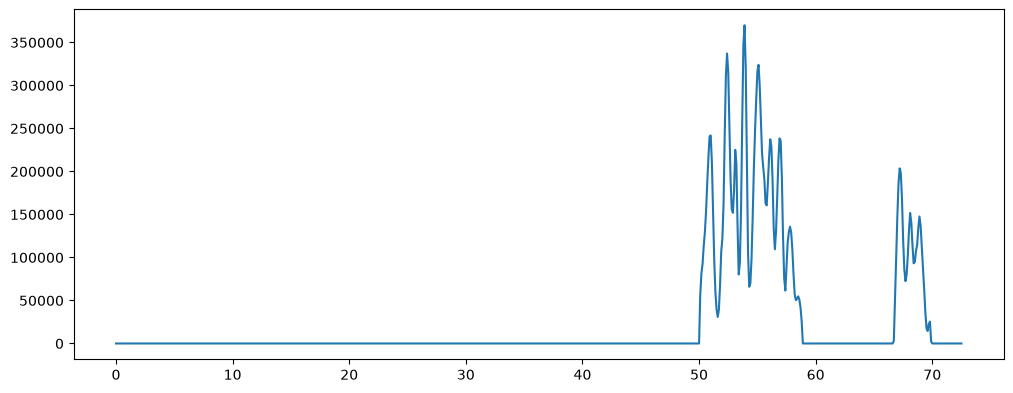

In [7]:
plot.figure(figsize=(12, 10), facecolor='w', edgecolor='k')
plot.subplot(2,1,2)
plot.plot(t,shortfall90)


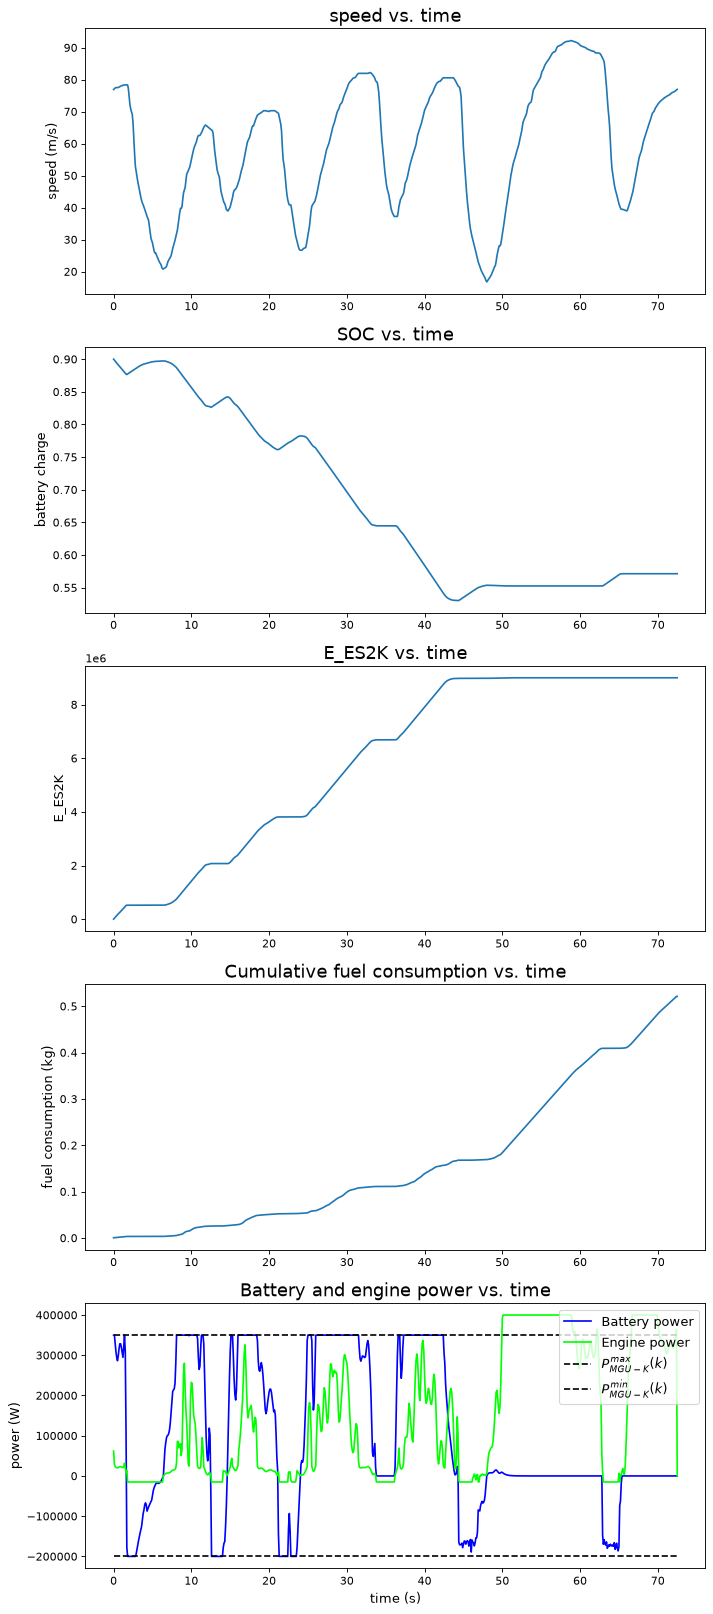

In [8]:
## Plot Simulation Results
plot.figure(num=5, figsize=(10, 25), dpi=80, facecolor='w', edgecolor='k')


plot.subplot(5,1,1)
# UDDS speed versus time 
plot.plot(t, v)
plot.ylabel('speed (m/s)', fontsize=12)
plot.title('speed vs. time', fontsize=16)


plot.subplot(5,1,2)
plot.plot(t, SOC_sim90)
plot.ylabel('battery charge', fontsize=12)
plot.title('SOC vs. time', fontsize=16)

plot.subplot(5,1,3)
plot.plot(t, E_ES2K_sim90)
plot.ylabel('E_ES2K', fontsize=12)
plot.title('E_ES2K vs. time', fontsize=16)

plot.subplot(5,1,4)
plot.plot(t, np.cumsum(J_sim90))
plot.ylabel('fuel consumption (kg)', fontsize=12)
plot.title('Cumulative fuel consumption vs. time', fontsize=16)


plot.subplot(5,1,5)
plot.plot(t, P_MGUK_sim90, 'blue', label='Battery power')
plot.plot(t, P_eng_sim90, 'lime', label='Engine power')
plot.plot(t, P_MGU_max*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}(k)$')
plot.plot(t, P_MGU_min*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}(k)$')
plot.ylabel('power (W)', fontsize=12)
plot.title('Battery and engine power vs. time', fontsize=16)
plot.xlabel('time (s)', fontsize=12)
plot.legend(loc=1, fontsize=12)